In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
#Loading the dataset

data = pd.read_csv('../data/car_price_prediction.csv')

data.head(1)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


In [10]:
# #Exploring the dataset and information

print("Sample data :",data.sample(5))

print("Data information :",data.info())
print("Shape of the dataset :",data.shape)
print("Columns :",data.columns) 





# #dataset contains no missing values, with datatypes of columns being either object or int64. , which is a continuous variable. The other columns are categorical variables, which will need to be encoded before training the model.








Sample data :              ID  Price  Levy Manufacturer       Model  Prod. year   Category  \
5777   45650365    314  1750       TOYOTA  Highlander        2008       Jeep   
19033  45644808    549  1750       TOYOTA  Highlander        2008       Jeep   
2655   45792144   3293   586        HONDA       Civic        2012      Sedan   
10044  45810222   1019   765          BMW         328        2015      Sedan   
4342   45806818    706   645        LEXUS     CT 200h        2011  Hatchback   

      Leather interior Fuel type Engine volume    Mileage  Cylinders  \
5777               Yes    Hybrid           3.3       0 km        6.0   
19033              Yes    Hybrid           3.3  260053 km        6.0   
2655               Yes    Petrol           1.8  124509 km        4.0   
10044              Yes    Petrol             2  111166 km        4.0   
4342               Yes    Hybrid           1.8  122302 km        4.0   

      Gear box type Drive wheels   Doors       Wheel   Color  Airbags  


In [11]:
#Statistical summary & info
pd.set_option('display.float_format', '{:.2f}'.format)
display(data.describe())

data.isnull().sum()

#Price and mileage looks a bit awkward at max,std and mean, perhaps wrong values or considerable outliers.


,ID,Price,Prod. year,Cylinders,Airbags
count,19237.00,19237.00,19237.00,19237.00,19237.00
mean,45576535.89,18555.93,2010.91,4.58,6.58
std,936591.42,190581.27,5.67,1.20,4.32
min,20746880.00,1.00,1939.00,1.00,0.00
25%,45698374.00,5331.00,2009.00,4.00,4.00
50%,45772308.00,13172.00,2012.00,4.00,6.00
75%,45802036.00,22075.00,2015.00,4.00,12.00
max,45816654.00,26307500.00,2020.00,16.00,16.00


ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [12]:
#Duplicate rows check

print("Duplicates in the dataset :",data.duplicated().sum())

#number of duplicates is 313 wich is not a lot but still considerable, so we will drop them to avoid any bias in the model.

data = data.drop_duplicates()




Duplicates in the dataset : 313


In [13]:
#Datatype conversion and quality
data["Levy"] = data["Levy"].replace("-", 0)
data["Levy"] = pd.to_numeric(data["Levy"])


data["Engine volume"] = data["Engine volume"].str.replace("Turbo","")
data["Engine volume"] = pd.to_numeric(data["Engine volume"])


data["Mileage"] = data["Mileage"].str.replace("km", '')
data["Mileage"]= pd.to_numeric(data["Mileage"])

#Mileage, Levy and Engine volume are supposed to be numerical, we converted them to numeric datatype


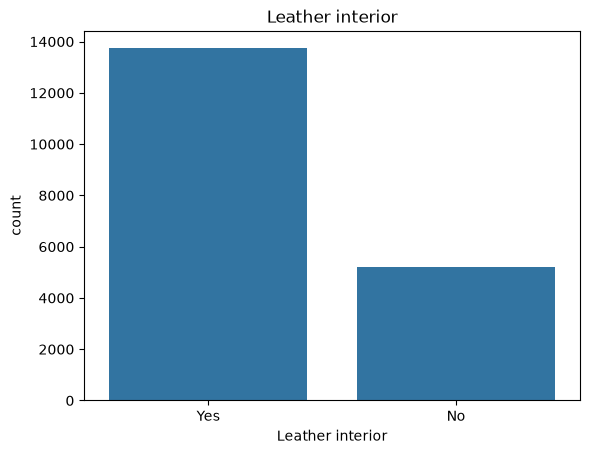

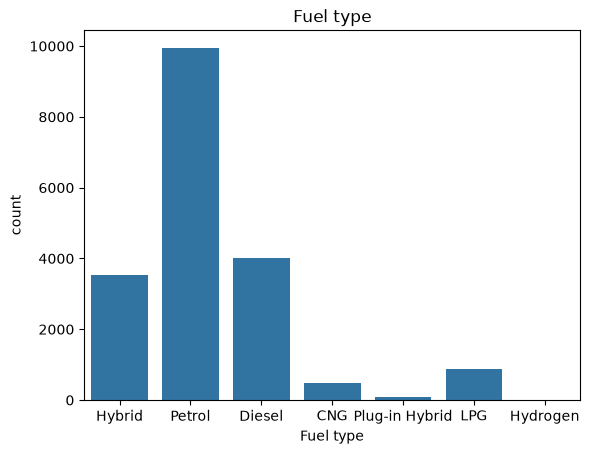

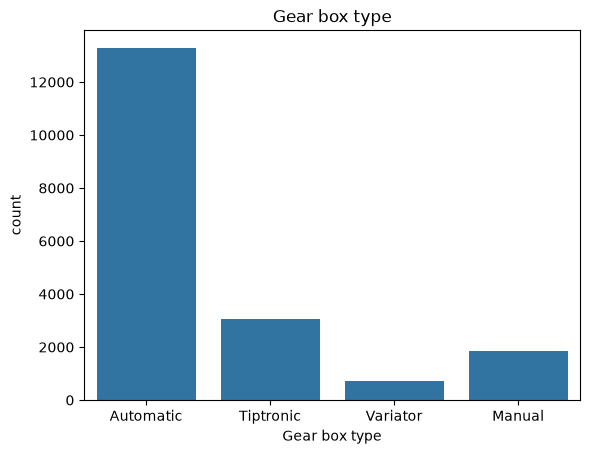

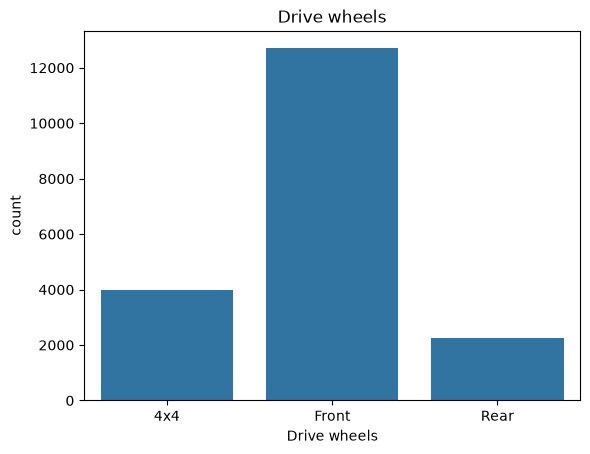

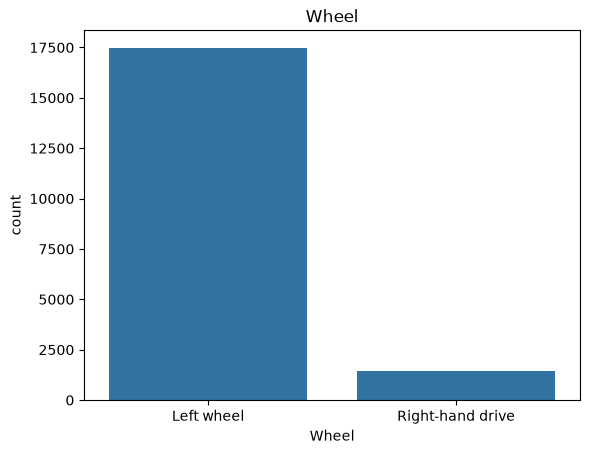

In [18]:
#Analyzing every column and its distribution, outliers and relationship with the target variable.

# for col in data.select_dtypes('number').columns:
#     sns.kdeplot((data[col]))
#     plt.show()
#     sns.boxplot((data[col]))
#     plt.show()

# #Price , Levy and Mileage seems very highly skewed, perhaps some massive outliers. We will need to handle them before training the model
# # we will try log transformation for now to take some ideas about normal distribution

# for col in data.select_dtypes('number').columns:
#     sns.kdeplot((np.log1p(data[col])))
#     plt.show()
#     sns.boxplot(np.log1p(data[col]))
#     plt.show()


categories = data[["Leather interior","Fuel type","Gear box type","Drive wheels","Wheel"]]

for col in categories.columns:
    sns.countplot(x = data[col])
    plt.title(col)
    plt.show()

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

data = remove_outliers(data, "Levy")
data = remove_outliers(data, "Mileage")
data = remove_outliers(data, "Price")


<Axes: ylabel='Mileage'>

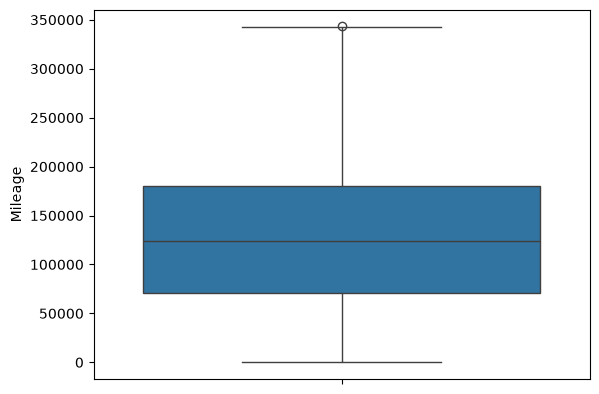

In [ ]:
sns.boxplot(y=data["Mileage"])